# Loading Libraries & Dataframes

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import randint
from imblearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, StratifiedKFold, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, precision_recall_curve, average_precision_score, roc_auc_score, f1_score, confusion_matrix
from sklearn import svm
from sklearn.calibration import CalibratedClassifierCV

from xgboost import XGBClassifier

from lightgbm import LGBMClassifier

from skopt.searchcv import BayesSearchCV
from skopt.space import Real, Integer, Categorical

In [2]:
df_training = pd.read_csv('customer_churn_dataset-training-master.xls')
df_testing = pd.read_csv('customer_churn_dataset-testing-master.xls')
df_training

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.00,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.00,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.00,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.00,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.00,20.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
440828,449995.0,42.0,Male,54.0,15.0,1.0,3.0,Premium,Annual,716.38,8.0,0.0
440829,449996.0,25.0,Female,8.0,13.0,1.0,20.0,Premium,Annual,745.38,2.0,0.0
440830,449997.0,26.0,Male,35.0,27.0,1.0,5.0,Standard,Quarterly,977.31,9.0,0.0
440831,449998.0,28.0,Male,55.0,14.0,2.0,0.0,Standard,Quarterly,602.55,2.0,0.0


# EDA

In [3]:
print(df_training.info())
print(df_testing.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Cou

In [4]:
print(df_training.duplicated().sum())
print(df_testing.duplicated().sum())

0
0


In [5]:
print(df_training.isna().sum())
print(df_testing.isna().sum())

CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64
CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64


In [6]:
df_training[df_training.isna().any(axis = 1)]

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
199295,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df_training = df_training.dropna()

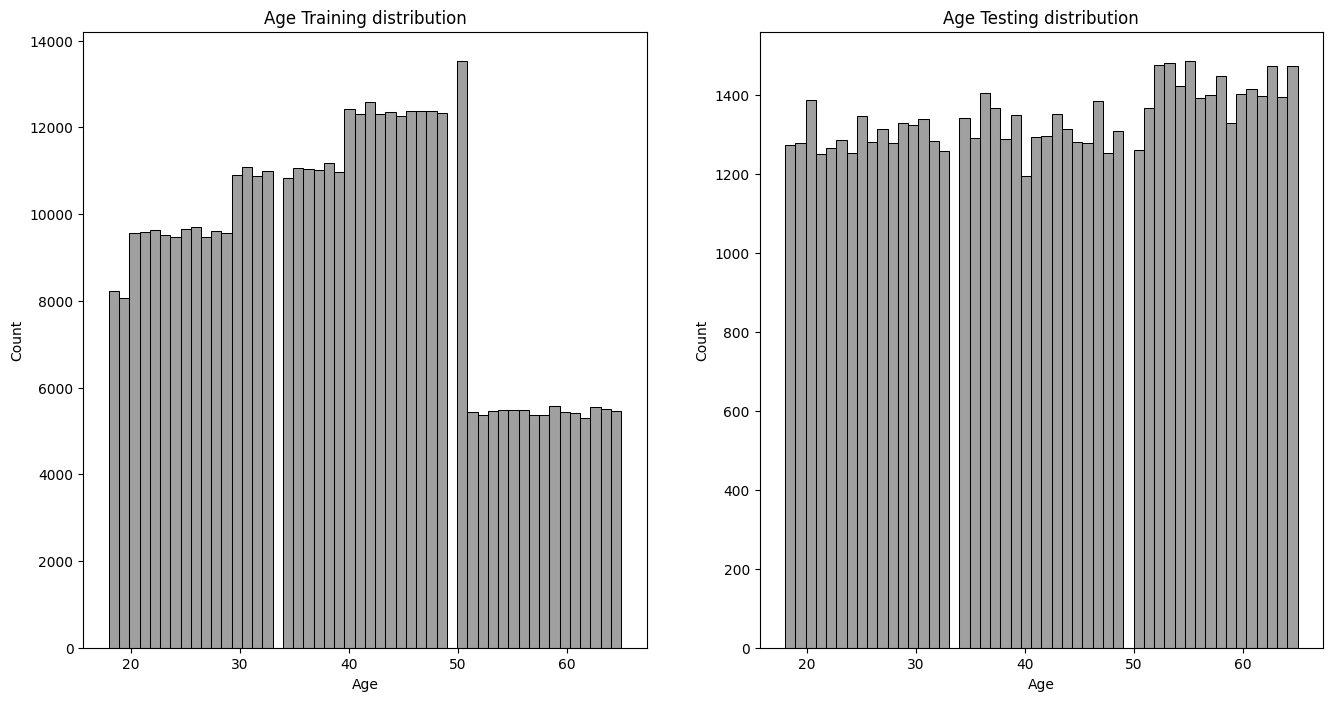

<Figure size 640x480 with 0 Axes>

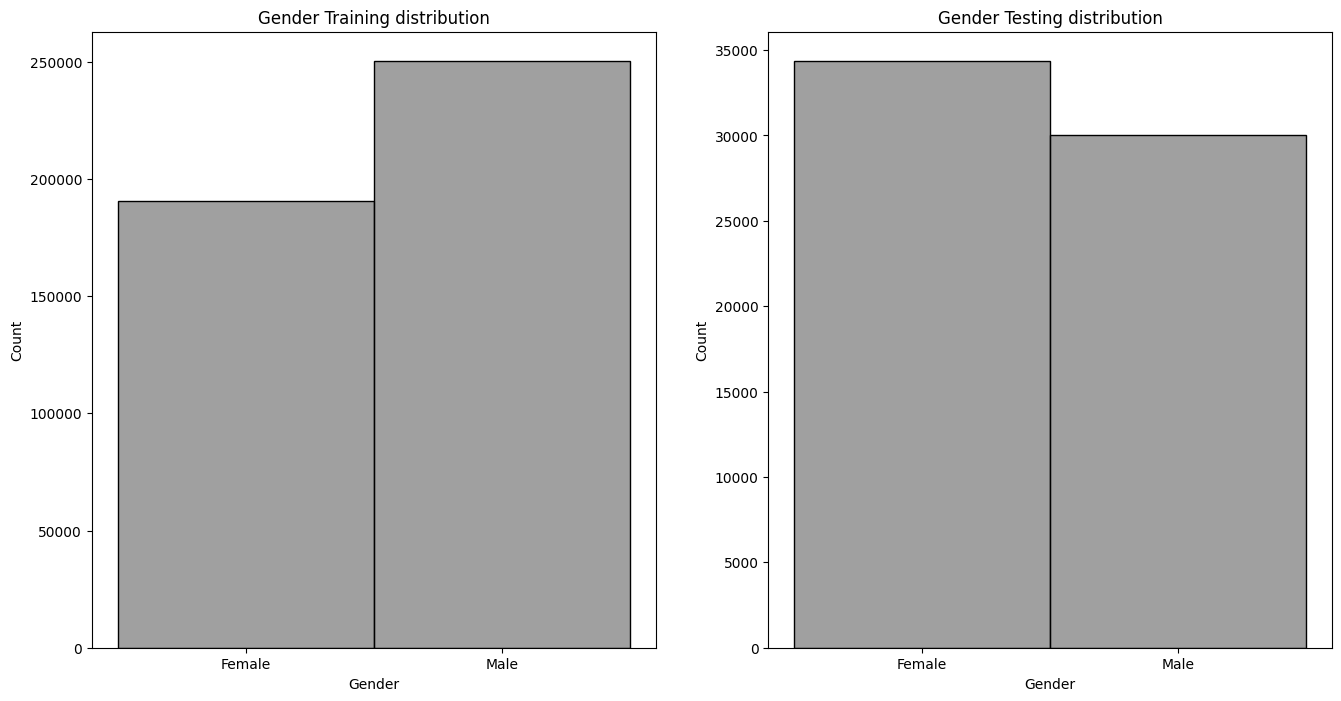

<Figure size 640x480 with 0 Axes>

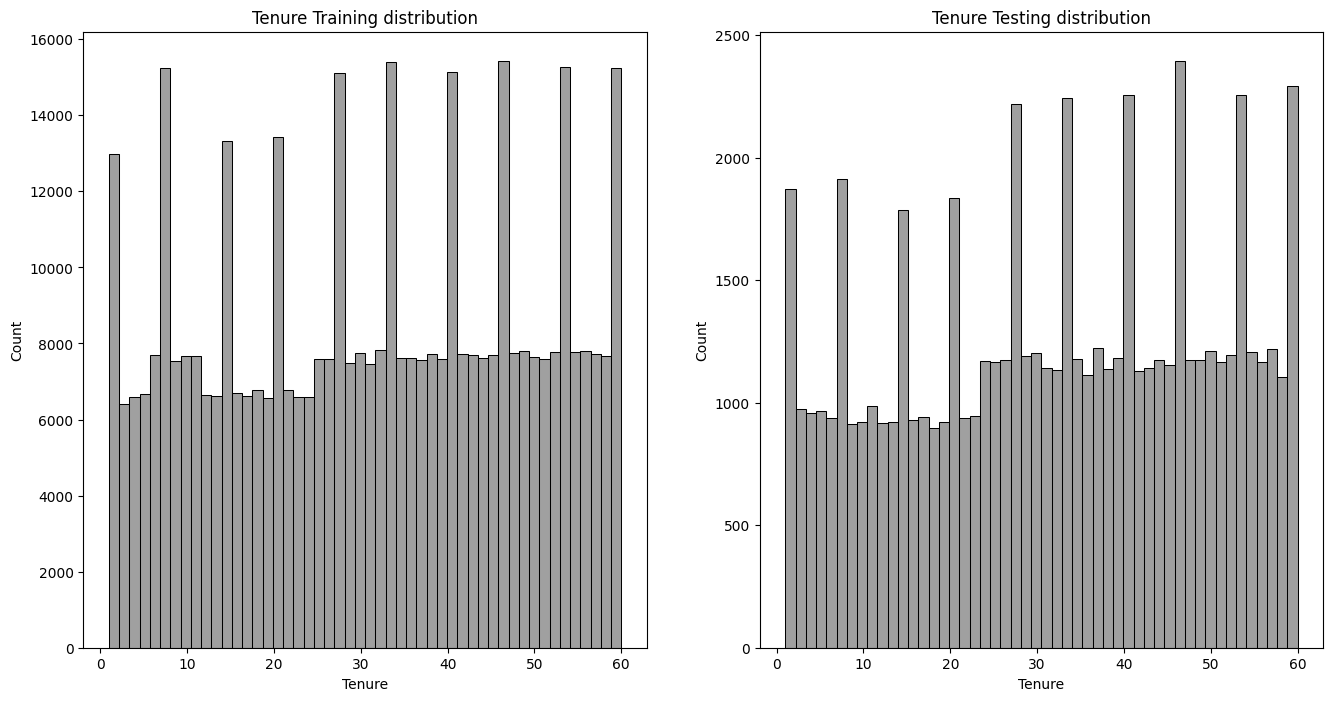

<Figure size 640x480 with 0 Axes>

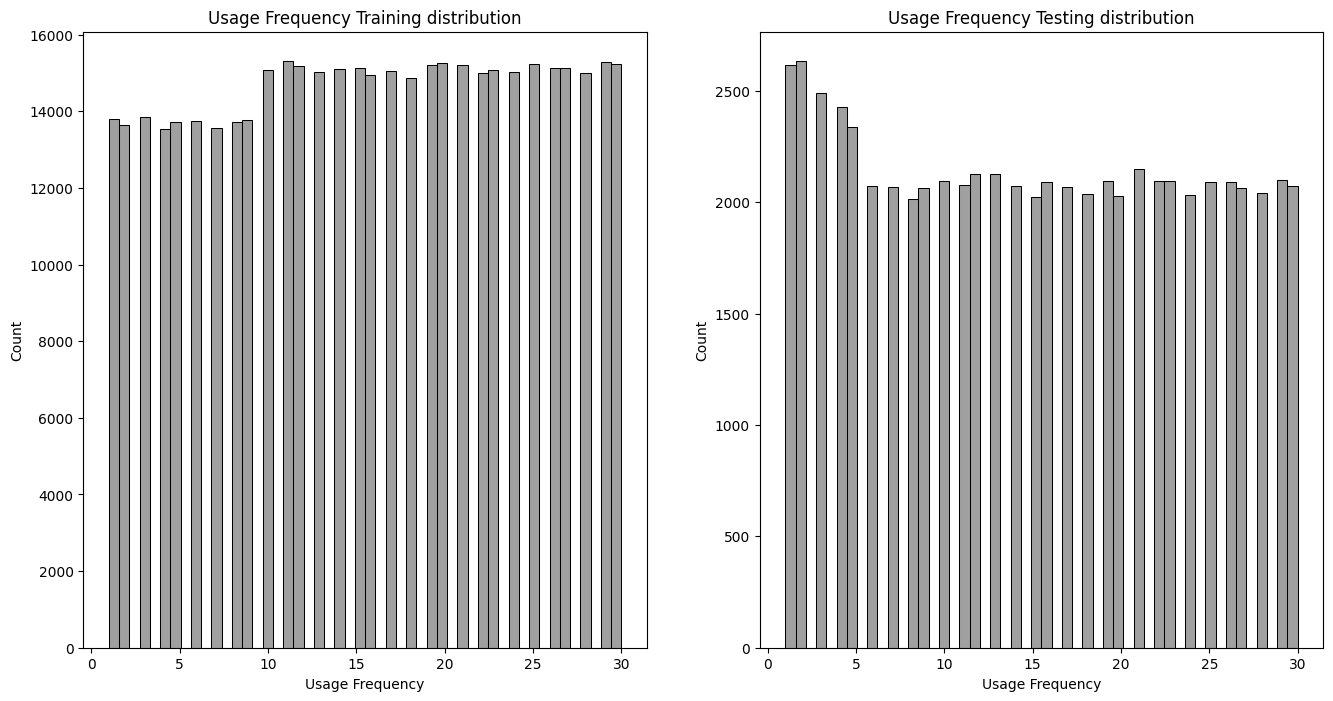

<Figure size 640x480 with 0 Axes>

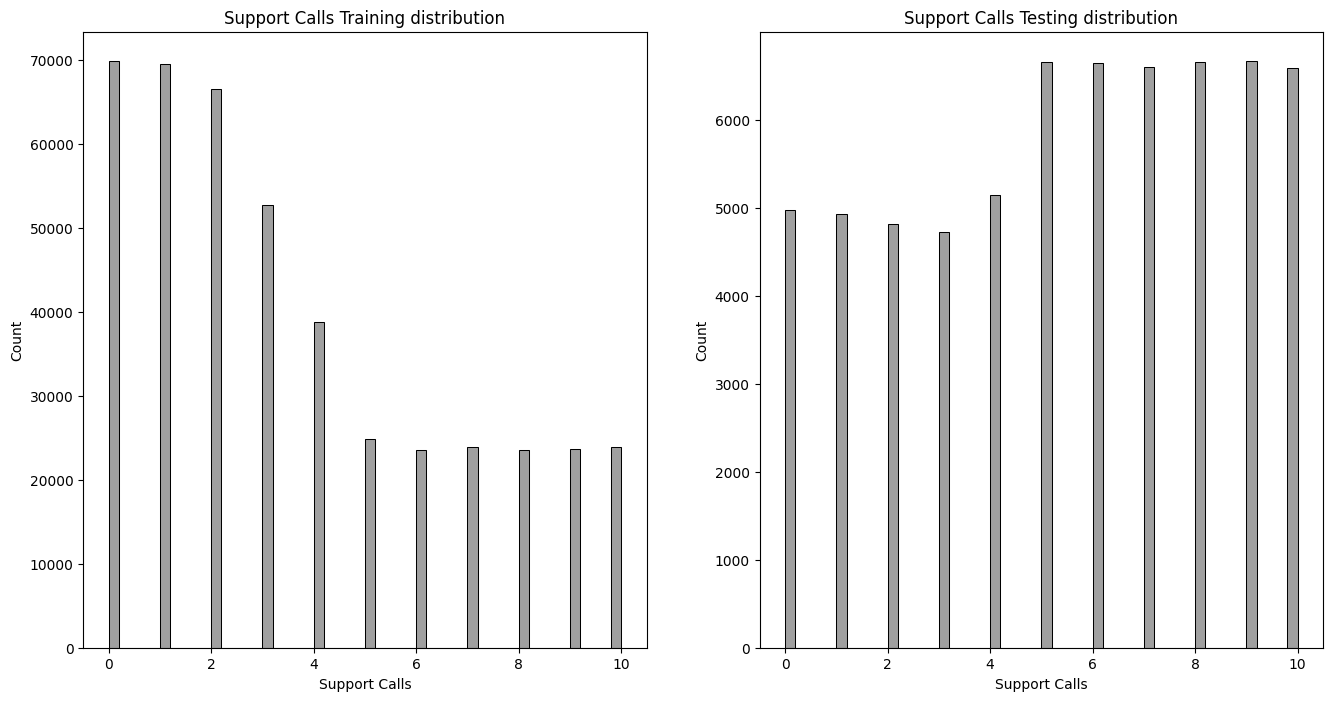

<Figure size 640x480 with 0 Axes>

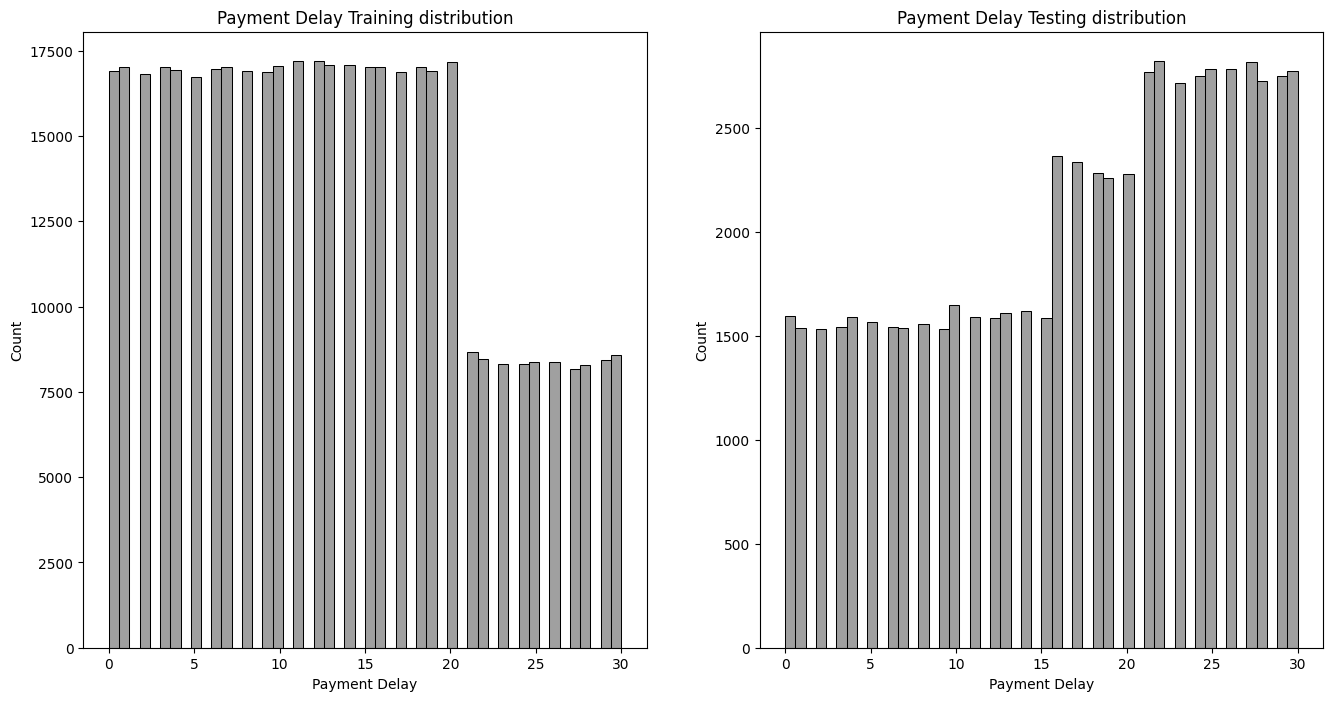

<Figure size 640x480 with 0 Axes>

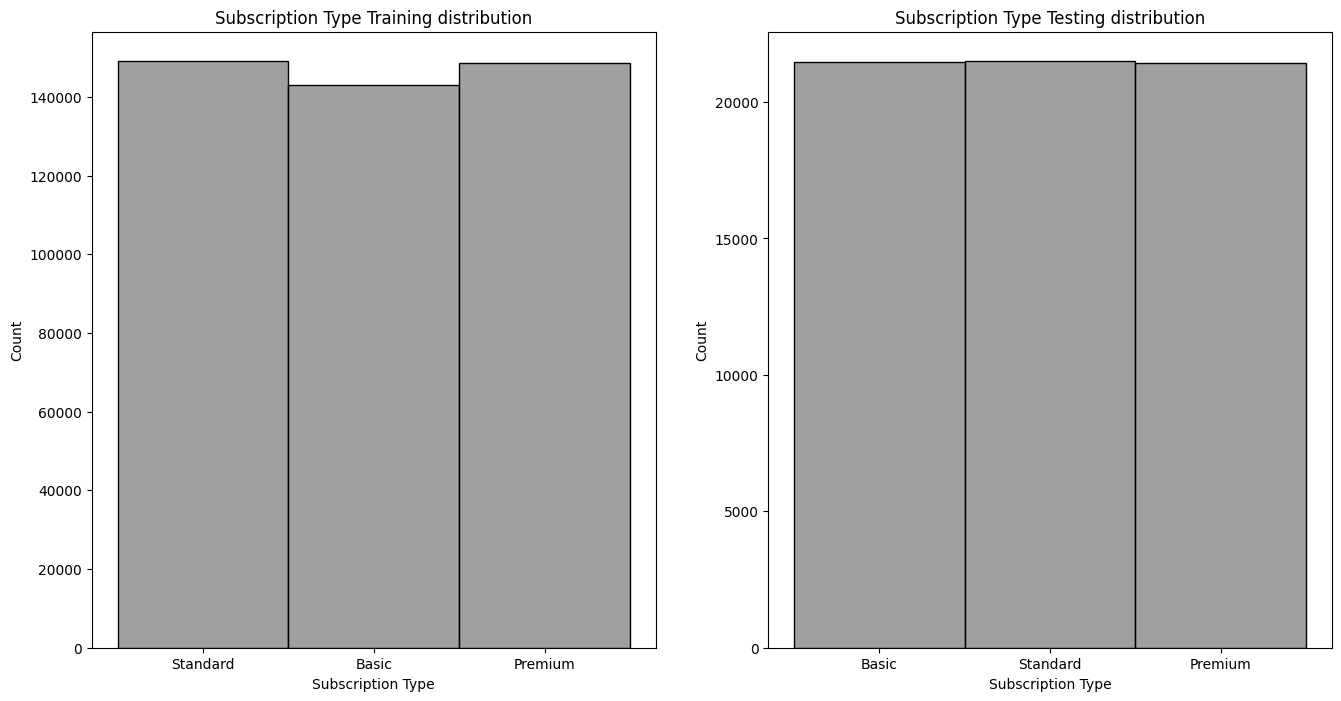

<Figure size 640x480 with 0 Axes>

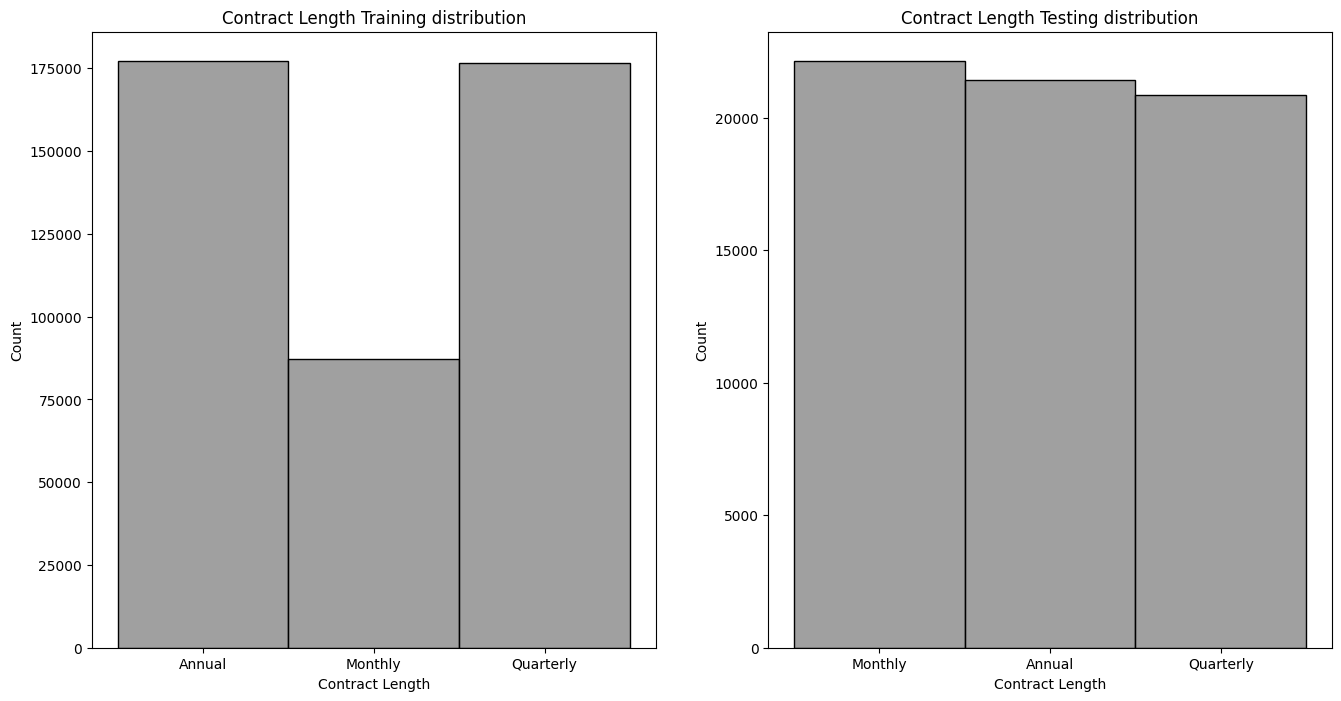

<Figure size 640x480 with 0 Axes>

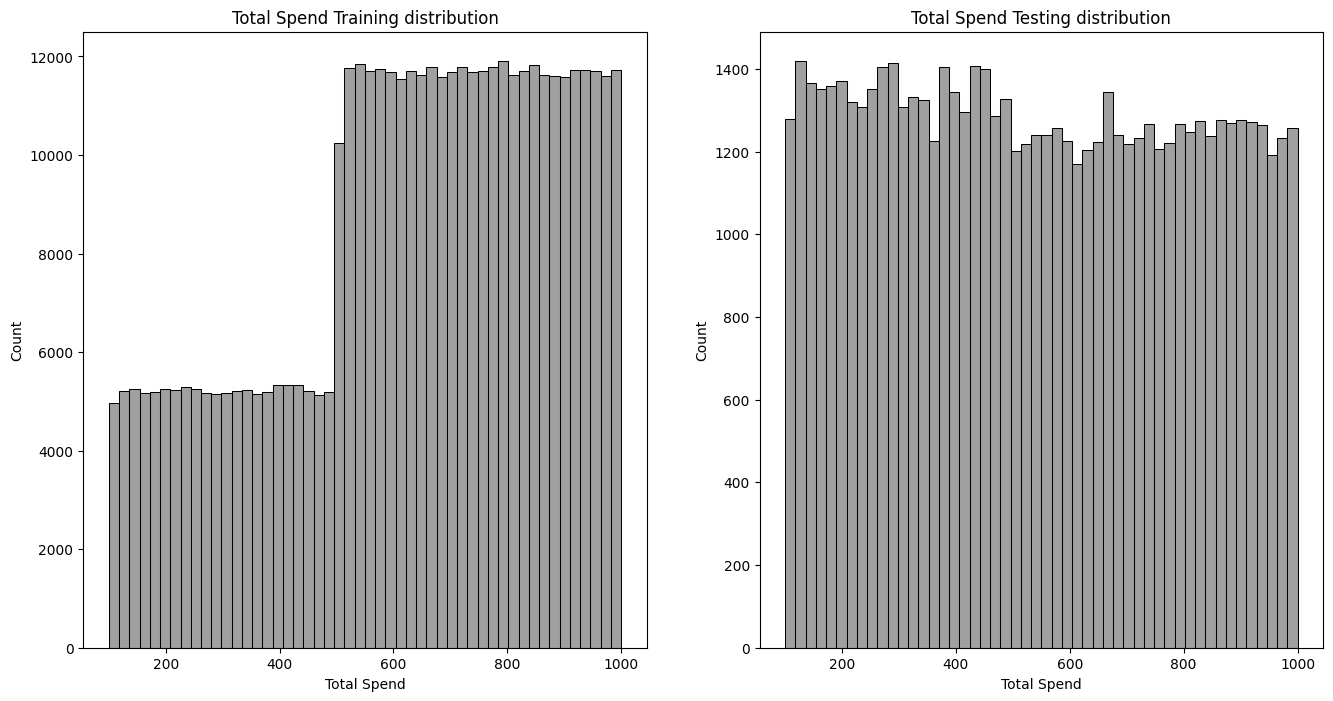

<Figure size 640x480 with 0 Axes>

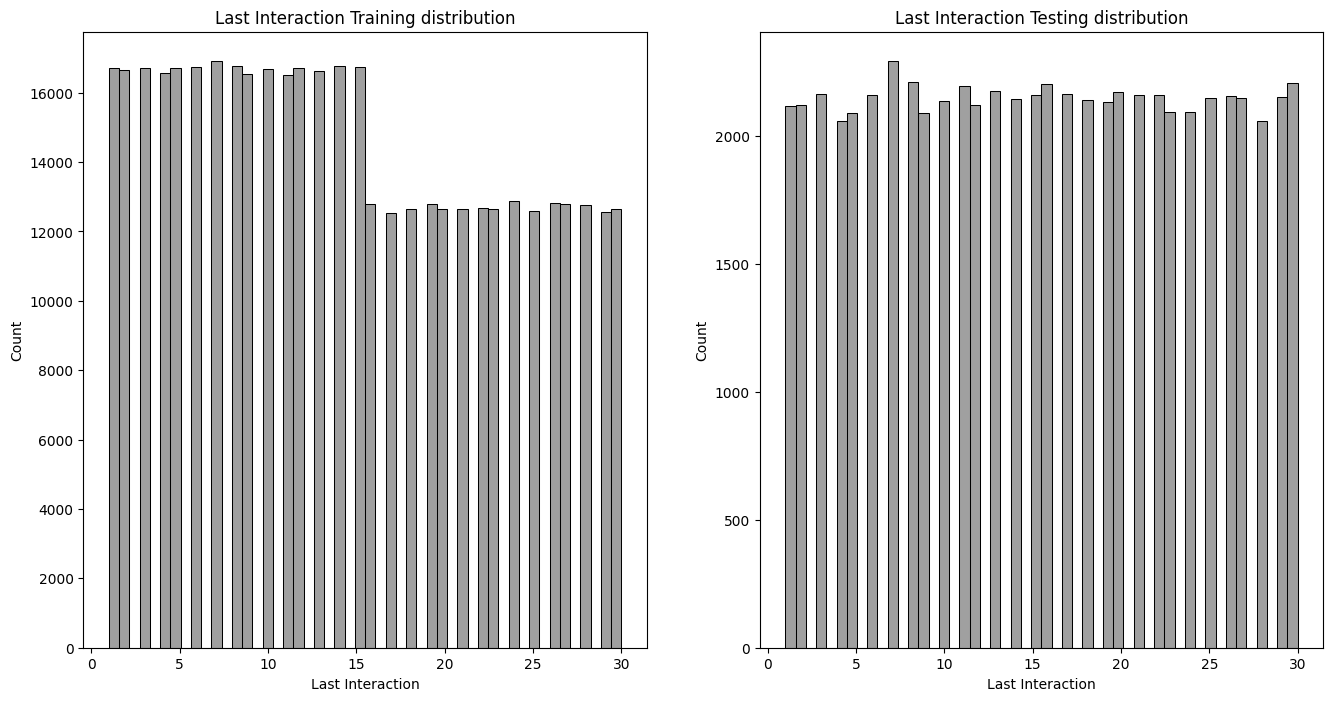

<Figure size 640x480 with 0 Axes>

In [8]:
for col in df_training.columns[1:-1]:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (16, 8))
    sns.histplot(df_training[col],
                 color = 'grey',
                 edgecolor = 'black',
                 bins = 50,
                 ax = ax1)
    ax1.set_title(f'{col} Training distribution')
    sns.histplot(df_testing[col],
                 color = 'grey',
                 edgecolor = 'black',
                 bins = 50,
                 ax = ax2)
    ax2.set_title(f'{col} Testing distribution')
    plt.show()
    plt.tight_layout()

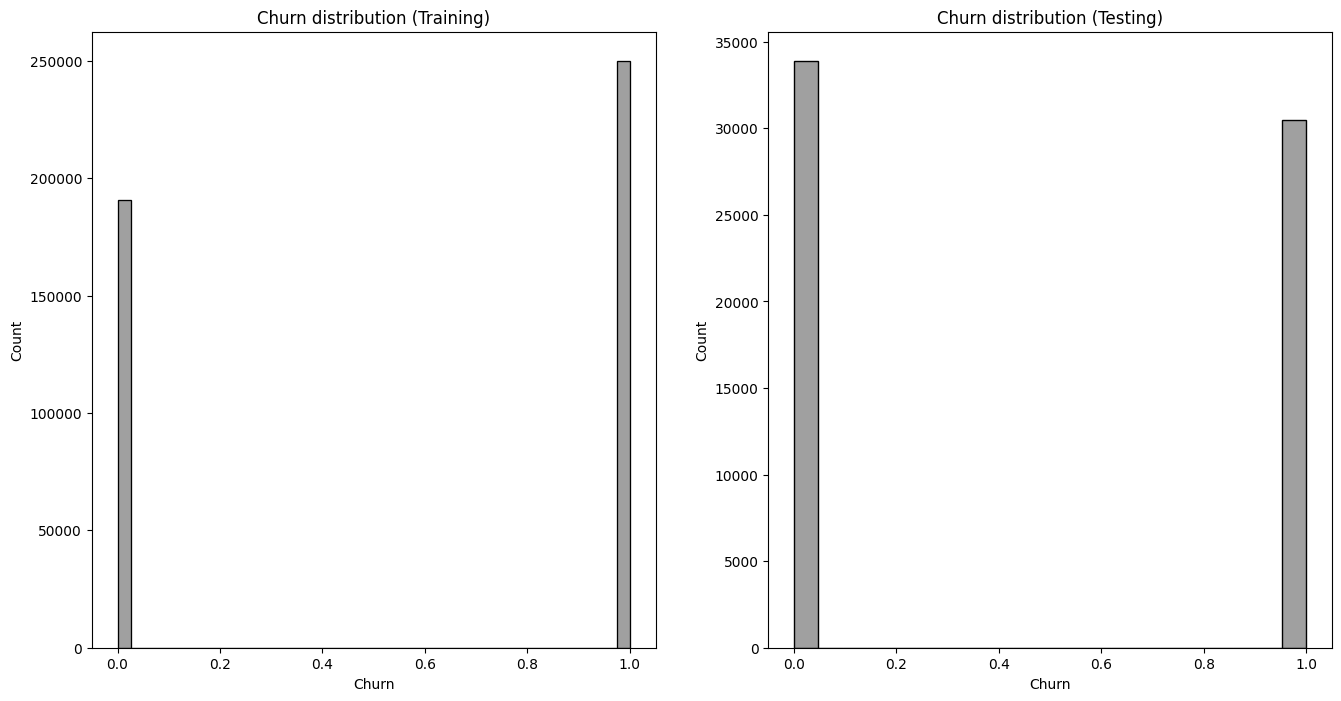

<Figure size 640x480 with 0 Axes>

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (16, 8))
sns.histplot(df_training['Churn'],
                 color = 'grey',
                 edgecolor = 'black',
                 ax = ax1)
ax1.set_title('Churn distribution (Training)')
sns.histplot(df_testing['Churn'],
                 color = 'grey',
                 edgecolor = 'black',
                 ax = ax2)
ax2.set_title('Churn distribution (Testing)')
plt.show()
plt.tight_layout()

# Pipeline

In [ ]:
numeric_cols = ['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction']
cat_cols = ['Gender', 'Subscription Type', 'Contract Length']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=30)

def encode_train_classify(name, model, param_config, X_train, X_test, y_train, y_test):
    preprocessor = ColumnTransformer(transformers = [
        ('ohe',Pipeline([
            ('simple', SimpleImputer(strategy = 'most_frequent')),
            ('encoder', OneHotEncoder(drop = 'first', sparse_output = False, handle_unknown = 'ignore'))
        ]), cat_cols),
        ('std', Pipeline([
            ('imputer', KNNImputer(n_neighbors=10, weights='distance', metric='nan_euclidean')),
            ('scaler', StandardScaler())
        ]), numeric_cols)
    ], remainder = 'drop')
    
    pipe = Pipeline([
        ('Preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    params = {f'classifier__{key}': value for key, value in param_config['params'].items()}
    
    if not params:
        pipe.fit(X_train, y_train)
        best_pipe = pipe
        params_clean = {}
    
    elif param_config['method'] == 'Random':
        rand_search = RandomizedSearchCV(
            estimator = pipe,
            param_distributions = params,
            cv = skf,
            scoring = 'f1',
            n_jobs = -1,
            verbose = 1,
            random_state = 30
        )
        rand_search.fit(X_train, y_train)
        best_pipe = rand_search.best_estimator_
        params_clean = {key.replace('classifier__', ''): value for key, value in rand_search.best_params_.items()}

    
    elif param_config['method'] == 'Grid':
        grid_search = GridSearchCV(
            estimator = pipe,
            param_grid = params,
            cv = skf,
            scoring = 'f1',
            n_jobs = -1,
            verbose = 1,
        )
        grid_search.fit(X_train, y_train)
        best_pipe = grid_search.best_estimator_
        params_clean = {key.replace('classifier__',''): value for key, value in grid_search.best_params_.items()}

    
    else:
        bayes_search = BayesSearchCV(
            estimator = pipe,
            search_spaces = params,
            cv = skf,
            scoring = 'f1',
            verbose = 0,
            random_state = 30
        )
        bayes_search.fit(X_train, y_train)
        best_pipe = bayes_search.best_estimator_
        params_clean = {key.replace('classifier__', ''): value for key, value in bayes_search.best_params_.items()}

    y_pred = best_pipe.predict(X_test)
    if hasattr(best_pipe.named_steps['classifier'], 'predict_proba'): # Model probability checks, SVM generates decision_function()
        y_proba = best_pipe.predict_proba(X_test)[:, 1]
    else:
        y_proba = best_pipe.decision_function(X_test)
        
    roc_auc = roc_auc_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    avg_per = average_precision_score(y_test, y_pred)
    
        
    print(f'<<<<<<<<<<<<<<<<<<<< {name} >>>>>>>>>>>>>>>>>>>>')
    print(f'Classification Report:\n{classification_report(y_test, y_pred)}')
    print(f'\nBest Parameters: {params_clean}')
    print(f'ROC AUC Score: {roc_auc}')
    print('<<<<<<<<<<<<<<<<<<<<<<<  >>>>>>>>>>>>>>>>>>>>>>>')
    
    return best_pipe, y_pred, y_proba, params_clean, f1, avg_per

In [11]:
df = pd.concat([df_training, df_testing], ignore_index=True)
df = df.dropna(how='all')
X = df.drop(columns=['CustomerID', 'Churn'])
y = df['Churn'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify= y,
    random_state=30
)

print('Train churn rate:', y_train.mean().round(2))
print('Test churn rate:', y_test.mean().round(2))

print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts())
print(y_test.value_counts())

Train churn rate: 0.56
Test churn rate: 0.56
(404164, 10)
(101042, 10)
Churn
1    224393
0    179771
Name: count, dtype: int64
Churn
1    56099
0    44943
Name: count, dtype: int64


# Models

In [ ]:
negative_cases = (y_train == 0).sum()
positive_cases = (y_train == 1).sum()
scale_pos_weight = negative_cases / positive_cases
print(f'scale_pos_weight: {scale_pos_weight}')

models = [
    {'name': 'Logistic Regression',
    'model': LogisticRegression(random_state = 30),
    'param_config': {'method':None, 'params': {}}},
    {'name': 'Random Forest Classifier',
     'model': RandomForestClassifier(random_state = 30),
     'param_config': {'method': 'Random',
                      'params': {'n_estimators': randint(100, 500),
                                 'max_depth': [20, 30, 40],
                                 'min_samples_split': randint(2, 10),
                                 'max_features': ['sqrt', 'log2', 1]}}},
    {'name': 'XGBoost Classifier',
     'model': XGBClassifier(objective = 'binary:logistic',
                            random_state = 30,
                            n_jobs = 1,
                            tree_method = 'hist'),
     'param_config': {'method': 'Bayes',
                      'params': {'n_estimators': Integer(100, 500),
                                 'max_depth': Integer(5, 15),
                                 'eta': Real(0.01, 0.3, prior = 'log-uniform'), # using prior for broader range of learning rates
                                 'subsample': Real(0.5, 1),
                                 'colsample_bytree': Real(0.5, 1)}}}
          ]

results = {}

best_pipe, y_pred, y_proba, params_clean, f1, avg_per = encode_train_classify(models[0]['name'],
                                                                              models[0]['model'],
                                                                              models[0]['param_config'], X_train, X_test, y_train, y_test)
results['Logistic Regression'] = {
    'pipe': best_pipe,
    'params': params_clean,
    'y_pred': y_pred,
    'y_proba': y_proba,
    'F1': f1,
    'per_score': avg_per
    }

scale_pos_weight: 0.8011435294327364
<<<<<<<<<<<<<<<<<<<< Logistic Regression >>>>>>>>>>>>>>>>>>>>
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.85      0.83     44943
           1       0.87      0.85      0.86     56099

    accuracy                           0.85    101042
   macro avg       0.85      0.85      0.85    101042
weighted avg       0.85      0.85      0.85    101042


Best Parameters: {}
ROC AUC Score: 0.8483924110568298
<<<<<<<<<<<<<<<<<<<<<<<  >>>>>>>>>>>>>>>>>>>>>>>


In [13]:
best_pipe, y_pred, y_proba, params_clean, f1, avg_per = encode_train_classify(models[1]['name'],
                                                                              models[1]['model'],
                                                                              models[1]['param_config'], X_train, X_test, y_train, y_test)
results['Random Forest Classifier'] = {
    'pipe': best_pipe,
    'params': params_clean,
    'y_pred': y_pred,
    'y_proba': y_proba,
    'F1': f1,
    'per_score': avg_per
    }

Fitting 5 folds for each of 10 candidates, totalling 50 fits


c:\Users\medo7\AppData\Local\Programs\Python\Python314\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


<<<<<<<<<<<<<<<<<<<< Random Forest Classifier >>>>>>>>>>>>>>>>>>>>
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.86      0.92     44943
           1       0.90      1.00      0.95     56099

    accuracy                           0.94    101042
   macro avg       0.95      0.93      0.93    101042
weighted avg       0.94      0.94      0.94    101042


Best Parameters: {'max_depth': None, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 431}
ROC AUC Score: 0.9280301126355821
<<<<<<<<<<<<<<<<<<<<<<<  >>>>>>>>>>>>>>>>>>>>>>>


In [14]:
best_pipe, y_pred, y_proba, params_clean, f1, avg_per = encode_train_classify(models[2]['name'],
                                                                              models[2]['model'],
                                                                              models[2]['param_config'], X_train, X_test, y_train, y_test)
results['XGBoost Classifier'] = {
    'pipe': best_pipe,
    'params': params_clean,
    'y_pred': y_pred,
    'y_proba': y_proba,
    'F1': f1,
    'per_score': avg_per
    }

<<<<<<<<<<<<<<<<<<<< XGBoost Classifier >>>>>>>>>>>>>>>>>>>>
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.86      0.92     44943
           1       0.90      1.00      0.95     56099

    accuracy                           0.94    101042
   macro avg       0.95      0.93      0.93    101042
weighted avg       0.94      0.94      0.94    101042


Best Parameters: {'colsample_bytree': 1.0, 'eta': 0.01, 'max_depth': 13, 'n_estimators': 336, 'subsample': 0.9935205663276876}
ROC AUC Score: 0.9282797347133334
<<<<<<<<<<<<<<<<<<<<<<<  >>>>>>>>>>>>>>>>>>>>>>>


# Checking for overfitting

In [16]:
for m in models:
    pipe = results[m['name']]['pipe']
    
    train_pred = pipe.predict(X_train)
    test_pred = results[m['name']]['y_pred']

    if hasattr(pipe.named_steps['classifier'], 'predict_proba'):
        train_proba = pipe.predict_proba(X_train)[:, 1]
        test_proba = pipe.predict_proba(X_test)[:, 1]
    else:
        train_proba = pipe.decision_function(X_train)
        test_proba = pipe.decision_function(X_test)
    
    train_f1 = f1_score(y_train, train_pred)
    test_f1 = f1_score(y_test, test_pred)
    train_roc = roc_auc_score(y_train, train_proba)
    test_roc = roc_auc_score(y_test, test_proba)
    
    print(f"<<<<<<<<<<<<<<<<<<< {m['name']} >>>>>>>>>>>>>>>>>>>")
    print(f"{'Metric':<15} {'Train':>10} {'Test':>10} {'Gap':>10}")
    print(f"{'F1':<15} {train_f1:>10.4f} {test_f1:>10.4f} {train_f1 - test_f1:>10.4f}")
    print(f"{'ROC AUC':<15} {train_roc:>10.4f} {test_roc:>10.4f} {train_roc - test_roc:>10.4f}")
    print('<<<<<<<<<<<<<<<<<<<<<<<  >>>>>>>>>>>>>>>>>>>>>>>')

<<<<<<<<<<<<<<<<<<< Logistic Regression >>>>>>>>>>>>>>>>>>>
Metric               Train       Test        Gap
F1                  0.8617     0.8616     0.0001
ROC AUC             0.9089     0.9084     0.0005
<<<<<<<<<<<<<<<<<<<<<<<  >>>>>>>>>>>>>>>>>>>>>>>
<<<<<<<<<<<<<<<<<<< Random Forest Classifier >>>>>>>>>>>>>>>>>>>
Metric               Train       Test        Gap
F1                  1.0000     0.9453     0.0547
ROC AUC             1.0000     0.9536     0.0464
<<<<<<<<<<<<<<<<<<<<<<<  >>>>>>>>>>>>>>>>>>>>>>>
<<<<<<<<<<<<<<<<<<< XGBoost Classifier >>>>>>>>>>>>>>>>>>>
Metric               Train       Test        Gap
F1                  0.9479     0.9456     0.0024
ROC AUC             0.9935     0.9536     0.0399
<<<<<<<<<<<<<<<<<<<<<<<  >>>>>>>>>>>>>>>>>>>>>>>


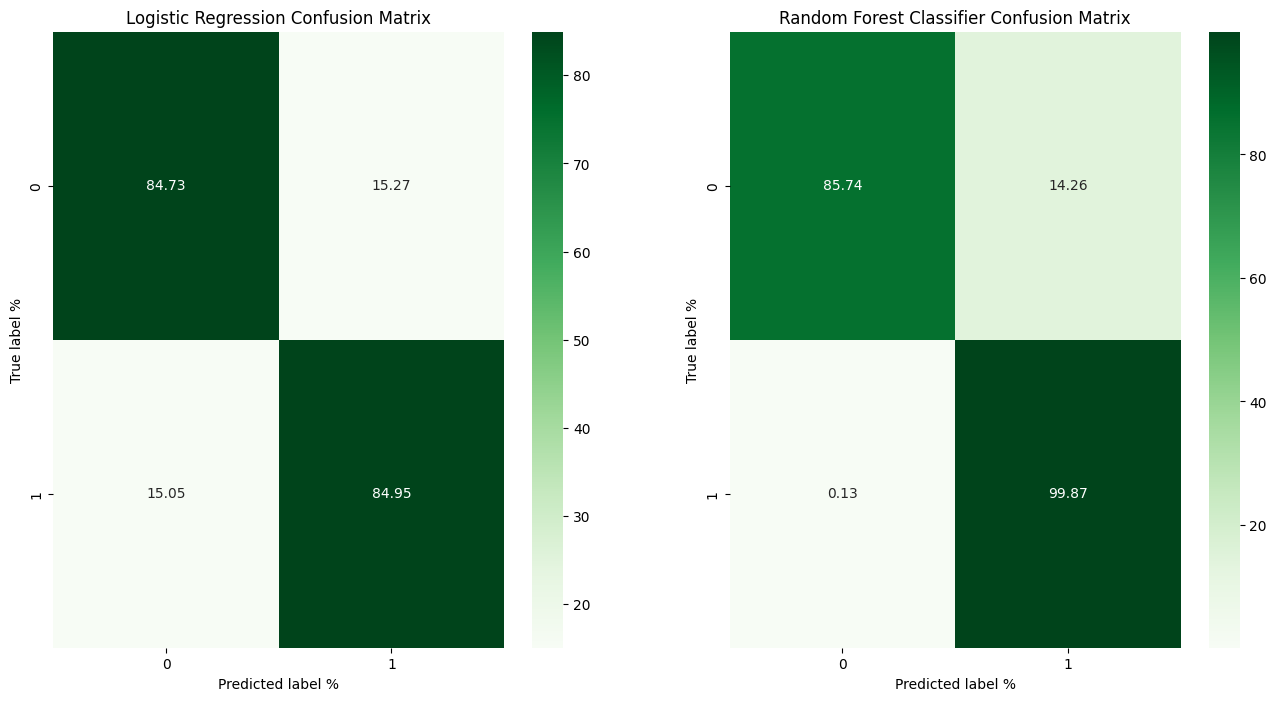

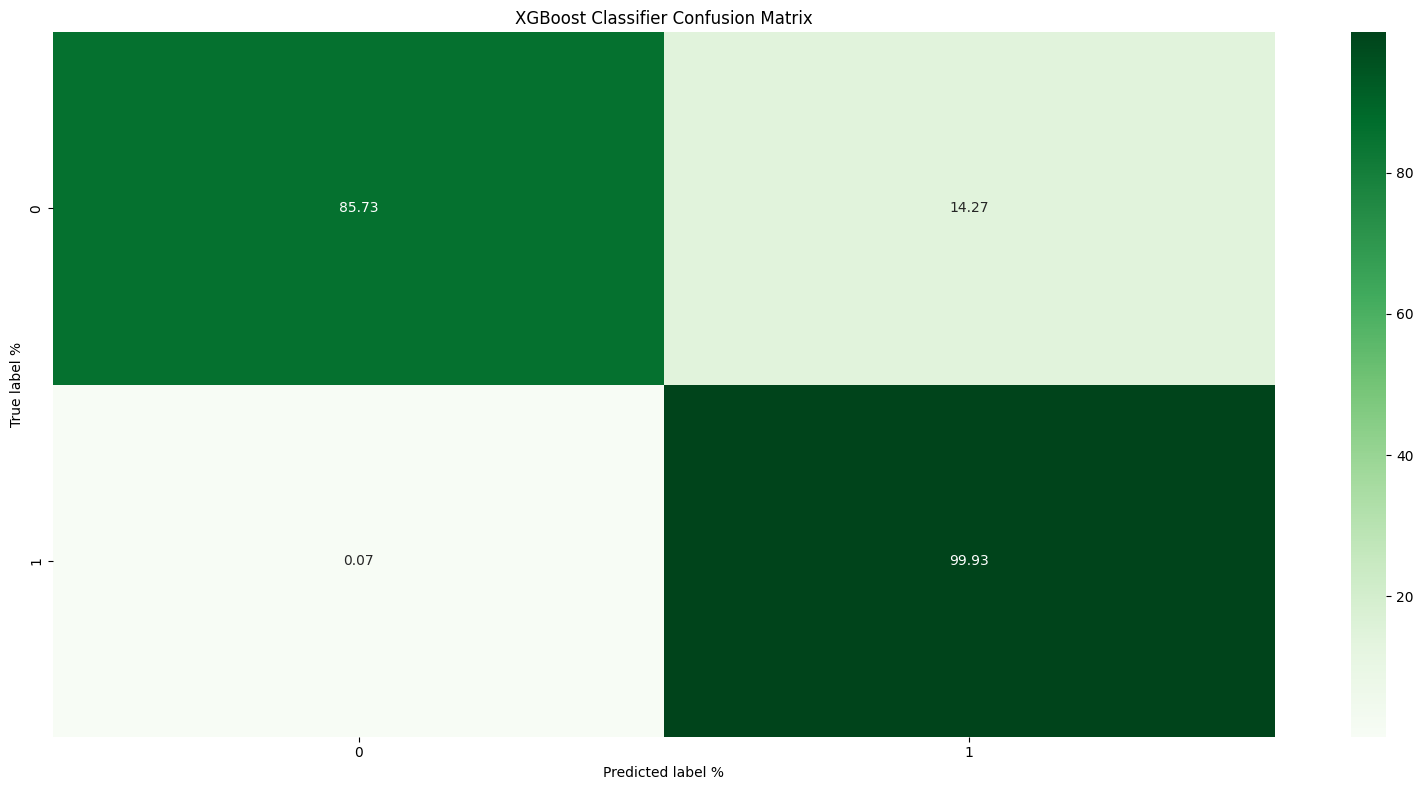

In [ ]:
fig, axes = plt.subplots(1, 2, figsize = (16, 8))
axes = axes.flatten() # flattens axes to  [ax1, ax2, ax3, ax4]

for m, ax in zip(models[: 4], axes): # zip takes lists and uses them as pairs
    cm = confusion_matrix(y_test, results[m['name']]['y_pred'])
    pct = cm.astype('float') / cm.sum(axis = 1)[:, np.newaxis] * 100
    sns.heatmap(pct,
                annot = True,
                cmap = 'Greens',
                fmt = '.2f',
                ax = ax)
    ax.set_title(f'{m['name']} Confusion Matrix')
    ax.set_xlabel('Predicted label %')
    ax.set_ylabel('True label %')

plt.figure(figsize = (14, 8))
cm = confusion_matrix(y_test, results['XGBoost Classifier']['y_pred'])
pct = cm.astype('float') / cm.sum(axis = 1)[:, np.newaxis] * 100
sns.heatmap(pct,
            annot = True,
            cmap = 'Greens',
            fmt = '.2f')
plt.title('XGBoost Classifier Confusion Matrix')
plt.xlabel('Predicted label %')
plt.ylabel('True label %')

plt.tight_layout()
plt.show()

Percision is very stable with boosting and ensemble models and less consistent as recall increases in linear models

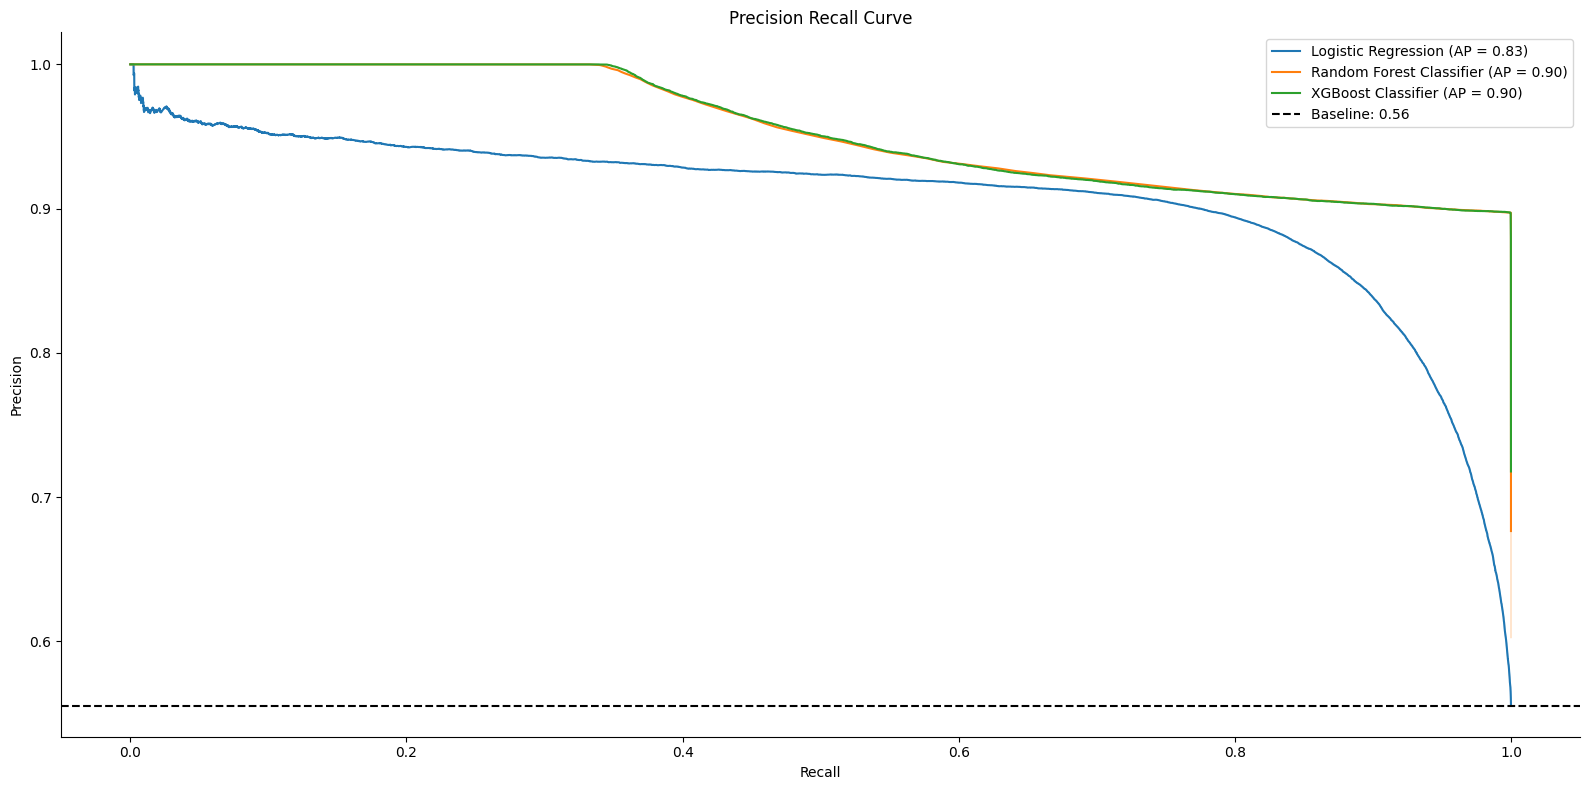

In [20]:
fig,  ax = plt.subplots(figsize = (16, 8))

for m in models:
    precision, recall, _ = precision_recall_curve(y_test, results[m['name']]['y_proba'])
    avg_prec = results[m['name']]['per_score']
    
    pr_df = pd.DataFrame({'Recall': recall, 'Precision': precision})
    sns.lineplot(data = pr_df,
                 x = 'Recall',
                 y = 'Precision',
                 label = f'{m['name']} (AP = {avg_prec:.2f})',
                 ax = ax)
    
baseline = y_test.sum() / len(y_test)
ax.axhline(y = baseline,
           color = 'black',
           linestyle = '--',
           label = f'Baseline: {baseline:.2f}')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision Recall Curve')
ax.legend(loc='upper right')
sns.despine()
plt.tight_layout()
plt.show()

# Conclusion
The issue was that the data was split into 2 files that have different distribution of the target variable `Churn` while also the having different datatypes for the variable. Training dataset had churn as `float64` while in the testing it was an `int64`.
The solution I came up with is adding them both into a new dataframe and then splitting it equally so the model can interpret the patterns better